# Kvantu Fāzes Novērtēšana

Quantum Phase Estimation (QPE) ir viens no svarīgākajiem kvantu algoritmiem. 
Tas nosaka fāzi φ, kas parādās, ja unitārs operators U darbojas uz savu eigenstāvokli.

Algoritma uzdevums ir noteikt skaitli φ, ja izpildās sakarība:

$$
U|\psi\rangle = e^{2\pi i \phi}|\psi\rangle
$$

kur:
- $U$ ir unitārs operators,
- $|\psi\rangle$ ir $U$ eigenstāvoklis,
- $\phi \in [0,1)$ ir meklējamā fāze.

Vienkārši sakot, QPE mēra, cik lielu fāzes pagriezienu operators U piešķir savam eigenstāvoklim.


### Fāzes reģistrs:
satur $t$ kubitus un nosaka rezultāta precizitāti.

### Sistēmas reģistrs:
satur stāvokli $|\psi\rangle$, uz kuru darbojas operators $U$.


### Algoritma soļi

1. Fāzes reģistrs tiek sagatavots superpozīcijā ar Hadamard.
2. Tiek pielietoti kontrolēti operatori $U^{2^k}$.
3. Tiek izpildīta inversā Kvantu Furjē transformācija (QFT⁻¹).
4. Fāzes reģistrs tiek nomērīts, iegūstot bināru skaitli, kas aproksimē φ.

Rezultāts ir φ binārā pierakstā:
$$
\phi \approx 0.b_1 b_2 \dots b_t
$$


![Alt text](quantum_phase_estimation.png)


## Piemērs

- **U operators** ir Pauli–Z vārti  
- **Eigenstāvoklis** ir: $ \psi\rangle = |1\rangle $

- Z vārti uz $|1\rangle$ piešķir fāzi: $-1 = e^{2\pi i \cdot 0.5}$

### Darbība
1. Pēdējais kubits tiek sagatavots stāvoklī: $|1\rangle$

2. Fāzes reģistra kubiti tiek ievietoti superpozīcijā ar Hadamard vārtiem.  

3. Tiek pielietoti kontrolētie vārti $Z^{2^k}$, kas uzkrāj fāzi binārā veidā.


4. Inversā Kvantu Furjē transformācija $\mathrm{QFT}^{-1}$, pārvērš uzkrāto fāzi klasiskā binārā skaitlī.

#### Kāpēc rezultāts 100 nozīmē fāzi 0.5?
QPE rezultāts ir bināra daļa:

$$
0.100_2 = \frac{1}{2} + 0\cdot\frac{1}{4} + 0\cdot\frac{1}{8} = 0.5
$$


## Augsta līmeņa piemērs

C:\Users\ovase\AppData\Local\Temp\ipykernel_22036\83351075.py:17: DeprecationWarning: The class ``qiskit.circuit.library.phase_estimation.PhaseEstimation`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.phase_estimation instead.
  qpe = PhaseEstimation(num_phase_qubits, unitary)


Mērījumu rezultāti(fāze + 1 sistēmas kubits):
1001 : 2048


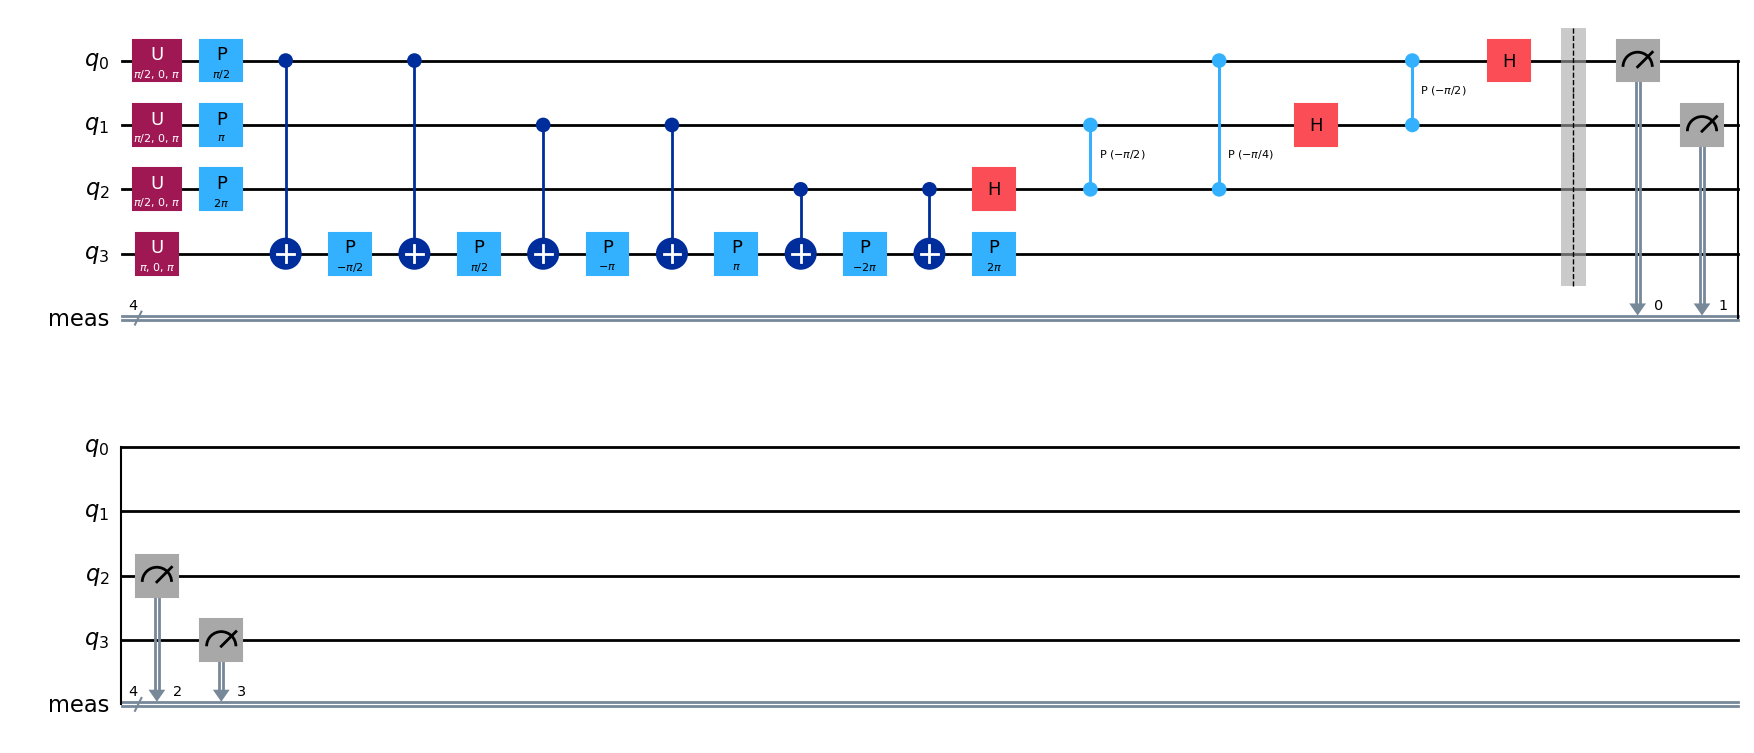

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import ZGate
from qiskit.circuit.library.phase_estimation import PhaseEstimation

num_phase_qubits = 3
shots = 2048

#Eigenstāvokļa sagatavošana |ψ⟩ = |1⟩
state_preparation = QuantumCircuit(1)
state_preparation.x(0)

#U operators, šaja piemērā Z vārti
unitary = ZGate()

# Quantum Phase Estimation
qpe = PhaseEstimation(num_phase_qubits, unitary)

qc = QuantumCircuit(num_phase_qubits + 1)
qc.append(state_preparation, [num_phase_qubits])
qc.append(qpe, range(num_phase_qubits + 1))
qc.measure_all()

# Simulācija
backend = AerSimulator()
qc_t = transpile(qc, backend)
result = backend.run(qc_t, shots=shots).result()
counts = result.get_counts()

print("Mērījumu rezultāti(fāze + 1 sistēmas kubits):")
for k, v in sorted(counts.items()):
    print(k, ":", v)

qc.decompose(reps=3).draw("mpl"

## Zema līmeņa piemērs

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

num_phase_qubits = 3
shots = 2048

def inverse_qft(qc: QuantumCircuit, qubits):
    n = len(qubits)
    for i in range(n // 2):
        qc.swap(qubits[i], qubits[n - 1 - i])
    for j in range(n):
        for m in range(j):
            angle = -np.pi / (2 ** (j - m))
            qc.cp(angle, qubits[m], qubits[j])
        qc.h(qubits[j])

qc = QuantumCircuit(num_phase_qubits + 1, num_phase_qubits + 1)
target = num_phase_qubits

# Eigenstāvoklis |ψ> = |1>
qc.x(target)

# Hadamardi fāzes reģistram
for q in range(num_phase_qubits):
    qc.h(q)

# Controlled-U^(2^k) 
# U = Z. Tad U^(2^k) = Z^(2^k).
for k in range(num_phase_qubits):
    reps = 2 ** k  # cik reižu jāpielietoto controlled-Z, lai imitētu (CZ)^(2^k)

    # CZ^2 = I, tāpēc pietiek ar reps % 2
    if reps % 2 == 1:
        qc.cz(k, target)
    # ja reps % 2 == 0 -> nekas nav jādara 

# Inversā QFT uz fāzes reģistra
inverse_qft(qc, list(range(num_phase_qubits)))

# Mērījumi
# qc ir QuantumCircuit(num_phase_qubits + 1, num_phase_qubits + 1)
target = num_phase_qubits

# target -> c0  pa labi, pēdējais bits stringā
qc.measure(target, 0)

# phase qubits -> c1..cN
for i in range(num_phase_qubits):
    qc.measure(i, i + 1)


backend = AerSimulator()
qc_t = transpile(qc, backend)
result = backend.run(qc_t, shots=shots).result()
counts = result.get_counts()

print("Mērījumu rezultāti:")
for k, v in sorted(counts.items()):
    print(k, ":", v)

qc.draw("mpl")
